# 02 — NLP : extraction par règles et classification de l'issue

Ce notebook contient toute la partie NLP du projet :

| Partie | Contenu |
|---|---|
| 1 | Chargement des données et découpage train / validation / test |
| 2 | **Extraction par règles** (regex) : métadonnées, textes de loi, issue |
| 3 | **Prétraitement NLP avec spaCy** : tokenisation, lemmatisation, mots vides |
| 4 | **Modèle A** : TF-IDF + régression logistique (et Naive Bayes) |
| 5 | **Modèle B** : réseau de neurones Keras (CNN) entraîné de zéro |
| 6 | **Modèle C** : CamemBERT pré-entraîné, fine-tuné |
| 7 | Comparaison des modèles |
| 8 | Analyse d'erreurs |
| 9 | Test « en production » sur les PDF réels (Bulletins 2026) |
| 10 | Sauvegarde du modèle final |

**La tâche de classification :** à partir des **motivations** (le raisonnement de la Cour), prédire l'**issue** de la décision
parmi 4 classes : *Rejet*, *Cassation*, *Irrecevabilité*, *Autre*.

Pourquoi les motivations et pas le texte entier ? Le **dispositif** (la fin, après « PAR CES MOTIFS ») écrit la réponse en toutes lettres
(« CASSE ET ANNULE », « REJETTE »). Une simple règle suffit alors (partie 2). Les motivations obligent le modèle à comprendre le raisonnement.

## 0. Configuration

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"    # CamemBERT en TensorFlow a besoin de Keras 2 (tf_keras)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # moins de messages techniques de TensorFlow
import warnings; warnings.filterwarnings("ignore")
import setuptools  # fournit "distutils", importé par TensorFlow 2.18 sous Python 3.12

import sys, time, json, random, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tf_keras as keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# QUICK_TEST=1 : version rapide du notebook sur peu de données (pour vérifier que tout fonctionne)
QUICK_TEST = os.environ.get("QUICK_TEST") == "1"

DATA, FIG, MODELS, RESULTS = "../data/processed", "../figures", "../models", "../results"
for d in (FIG, MODELS, RESULTS):
    os.makedirs(d, exist_ok=True)
sns.set_theme(style="whitegrid")

print("TensorFlow", tf.__version__, "| GPU :", tf.config.list_physical_devices("GPU"))
print("Mode test rapide :", QUICK_TEST)

TensorFlow 2.18.1 | GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mode test rapide : False


## 1. Données et découpage

On charge les **100 000 décisions** préparées par `scripts/prepare_data.py` (tirées au hasard parmi les 553 075).

On les découpe en trois parties **stratifiées** (chaque partie garde la même proportion de chaque classe) :
- **train (80 %)** : pour entraîner les modèles ;
- **validation (10 %)** : pour choisir les réglages (hyperparamètres) et le modèle final ;
- **test (10 %)** : jamais vu pendant l'entraînement, pour la note finale.

In [2]:
corpus = pd.read_parquet(f"{DATA}/corpus_model.parquet")
if QUICK_TEST:
    corpus = corpus.sample(3000, random_state=SEED)

LABELS = ["Rejet", "Cassation", "Irrecevabilité", "Autre"]
label2id = {l: i for i, l in enumerate(LABELS)}
corpus["y"] = corpus["label"].map(label2id)

train, temp = train_test_split(corpus, test_size=0.2, stratify=corpus["y"], random_state=SEED)
val, test = train_test_split(temp, test_size=0.5, stratify=temp["y"], random_state=SEED)

sizes = pd.DataFrame({s: d["label"].value_counts() for s, d in [("train", train), ("validation", val), ("test", test)]}).loc[LABELS]
sizes.loc["Total"] = sizes.sum()
sizes

,train,validation,test
label,,,
Rejet,44326,5540,5541
Cassation,20479,2560,2560
Irrecevabilité,3883,486,485
Autre,11312,1414,1414
Total,80000,10000,10000


### Métriques utilisées

- **Accuracy** : part des décisions bien classées. Trompeuse quand les classes sont déséquilibrées :
  un modèle qui répond toujours « Rejet » aurait déjà 55 % d'accuracy.
- **F1 d'une classe** : moyenne (harmonique) de la **précision** (quand le modèle dit « Cassation », a-t-il raison ?)
  et du **rappel** (parmi les vraies cassations, combien sont trouvées ?).
- **F1 macro** : moyenne des F1 des 4 classes, chaque classe comptant autant. **C'est notre métrique principale.**

In [3]:
def evaluate(name, y_true, y_pred, train_time=None, infer_time=None, n_train=None):
    """Calcule les métriques d'un modèle et les renvoie sous forme de dictionnaire."""
    f1s = f1_score(y_true, y_pred, labels=range(len(LABELS)), average=None, zero_division=0)
    res = {"modèle": name,
           "n_train": n_train,
           "accuracy": accuracy_score(y_true, y_pred),
           "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
           **{f"f1_{l}": f for l, f in zip(LABELS, f1s)},
           "temps_entraînement_s": train_time,
           "temps_inférence_ms_par_doc": None if infer_time is None else 1000 * infer_time / len(y_true)}
    print(f"{name:40s} accuracy={res['accuracy']:.4f}  F1 macro={res['f1_macro']:.4f}")
    return res

RESULTS_TABLE = []       # on y ajoute chaque modèle évalué sur le test
VAL_SCORES = {}          # F1 macro sur la validation (pour choisir le modèle final)
TEST_PREDS = {}          # prédictions sur le test (pour les matrices de confusion)

## 2. Extraction par règles (regex)

Une **expression régulière (regex)** est un motif de recherche. Par exemple `\d{2}-\d{2}\.\d{3}` signifie
« 2 chiffres, un tiret, 2 chiffres, un point, 3 chiffres » et retrouve les numéros de pourvoi comme `14-27.033`.

Les fonctions d'extraction sont dans `scripts/Txt_ToJSON.py` (le même code sert pour les PDF). On les évalue ici
sur **1 959 décisions** dont on connaît la bonne réponse grâce aux champs du dataset.

### 2.1 Issue déduite du dispositif
Règle simple : si le dispositif contient « CASSE » → Cassation ; « REJETTE » → Rejet ; « IRRECEVABLE » → Irrecevabilité ; sinon Autre.

In [4]:
sys.path.append("../scripts")
import Txt_ToJSON as t2j

t0 = time.time()
pred_rules = test["dispositif"].apply(t2j.verdict_from_dispositif).map(label2id)
t_rules = time.time() - t0
RESULTS_TABLE.append(evaluate("Règles (sur le dispositif)", test["y"], pred_rules, 0, t_rules, 0))
TEST_PREDS["Règles"] = pred_rules.values
print(classification_report(test["y"], pred_rules, target_names=LABELS, digits=3))

Règles (sur le dispositif)               accuracy=0.9630  F1 macro=0.9327
                precision    recall  f1-score   support

         Rejet      0.960     0.986     0.973      5541
     Cassation      0.988     0.989     0.988      2560
Irrecevabilité      0.922     0.806     0.860       485
         Autre      0.942     0.879     0.909      1414

      accuracy                          0.963     10000
     macro avg      0.953     0.915     0.933     10000
  weighted avg      0.963     0.963     0.962     10000



La règle est très forte sur *Rejet* et *Cassation* car le dispositif écrit la réponse. Elle est plus faible sur *Autre*,
une classe qui mélange plusieurs issues rares (déchéance, non-lieu, QPC…) écrites de façons variées.

### 2.2 Métadonnées, textes de loi et décision attaquée
Pour chaque champ, on compare la valeur extraite par regex avec la valeur du dataset.

In [5]:
ev = pd.read_parquet(f"{DATA}/eval_fulltext.parquet")
if QUICK_TEST:
    ev = ev.head(200)

def norm_court(s):
    """Normalise un nom de cour pour comparer : minuscules, apostrophes, espaces."""
    if not isinstance(s, str) or not s:
        return None
    s = s.lower().replace("’", "'").replace("d'", "de ").replace("-", " ")
    return " ".join(s.split())

rows = []
for _, r in ev.iterrows():
    text = t2j.clean_text(r["text"])
    meta = t2j.extract_metadata(text)
    prev = t2j.extract_previous_decision(text)
    found = set(t2j.extract_statutes(text))
    visa = set(s for v in r["visa"] for s in t2j.extract_statutes(t2j.clean_text(v or "")))
    rows.append({
        "year": int(r["date"][:4]),
        "date_ok": meta["date"] == r["date"],
        "chambre_ok": meta["chamber"] == r["chamber"],
        "numero_ok": meta["case_number"] == r["number"],
        "cour_attaquee_ok": (norm_court(prev["court"]) == norm_court(r["contested_jurisdiction"])) if isinstance(r["contested_jurisdiction"], str) else None,
        "visa_total": len(visa),
        "visa_trouves": len(visa & found),
    })
rule_eval = pd.DataFrame(rows)

summary = pd.Series({
    "Date (exact match)": rule_eval["date_ok"].mean(),
    "Chambre (exact match)": rule_eval["chambre_ok"].mean(),
    "N° de pourvoi (exact match)": rule_eval["numero_ok"].mean(),
    "Cour d'appel attaquée (exact match)": rule_eval["cour_attaquee_ok"].dropna().astype(float).mean(),
    "Textes de loi du visa retrouvés (rappel)": rule_eval["visa_trouves"].sum() / max(rule_eval["visa_total"].sum(), 1),
}).round(3)
summary.to_frame("score")

,score
Date (exact match),0.933
Chambre (exact match),0.962
N° de pourvoi (exact match),0.419
Cour d'appel attaquée (exact match),0.794
Textes de loi du visa retrouvés (rappel),0.985


Les scores dépendent beaucoup de l'**époque** de la décision : les décisions récentes ont un en-tête normalisé
(« Audience publique du… », « Pourvoi n°… »), les anciennes non. On le vérifie par période :

In [6]:
rule_eval["période"] = pd.cut(rule_eval["year"], [0, 1999, 2014, 2100], labels=["avant 2000", "2000-2014", "2015 et après"])
by_period = rule_eval.groupby("période", observed=True)[["date_ok", "chambre_ok", "numero_ok"]].mean().round(3)
by_period["nb décisions"] = rule_eval.groupby("période", observed=True).size()
by_period.to_csv(f"{RESULTS}/rules_by_period.csv")
summary.to_frame("score").to_csv(f"{RESULTS}/rules_summary.csv")
by_period

,date_ok,chambre_ok,numero_ok,nb décisions
période,,,,
avant 2000,0.933,1.000,0.029,626
2000-2014,0.978,1.000,0.021,535
2015 et après,0.904,0.906,0.992,798


## 3. Prétraitement NLP avec spaCy

**spaCy** est une bibliothèque de NLP. Son modèle français `fr_core_news_sm` découpe et analyse le texte :

| Étape | Rôle | Exemple |
|---|---|---|
| **Tokenisation** | découper le texte en mots (tokens) | « n'est » → `n'` + `est` |
| **Lemmatisation** | ramener chaque mot à sa forme de base | « violé », « viole », « violer » → `violer` |
| **Étiquetage (POS)** | nature du mot | `violer` → VERB |
| **Mots vides** (stop words) | mots très fréquents sans sens propre | « le », « de », « que » |

On retire les mots vides, la ponctuation et les chiffres, **sauf les négations** (« ne », « pas », « non »…) :
« le moyen **n'est pas** fondé » (rejet) ne doit pas devenir « moyen fondé » !

In [7]:
import spacy
nlp = spacy.load("fr_core_news_sm", disable=["parser", "ner"])   # on garde tokenisation, POS, lemmes

NEGATIONS = ["ne", "n'", "n’", "pas", "non", "ni", "sans", "aucun", "aucune", "jamais"]
for w in NEGATIONS:
    nlp.vocab[w].is_stop = False

exemple = "D'où il suit que le moyen n'est pas fondé ; qu'en statuant ainsi, la cour d'appel a violé le texte susvisé."
pd.DataFrame([{"token": t.text, "lemme": t.lemma_, "nature (POS)": t.pos_, "mot vide": t.is_stop, "ponctuation": t.is_punct}
              for t in nlp(exemple)])

,token,lemme,nature (POS),mot vide,ponctuation
0,D',de,ADP,True,False
1,où,où,PRON,True,False
2,il,il,PRON,True,False
3,suit,suivre,VERB,True,False
4,que,que,SCONJ,True,False
5,le,le,DET,True,False
6,moyen,moyen,NOUN,False,False
7,n',ne,ADV,False,False
8,est,être,AUX,True,False
9,pas,pas,ADV,False,False


In [8]:
def preprocess(doc):
    """Garde les lemmes (en minuscules) des vrais mots, sans mots vides ni ponctuation, mais avec les négations."""
    words = []
    for t in doc:
        if t.lower_ in NEGATIONS:
            words.append("ne" if t.lower_ in ("n'", "n’") else t.lower_)
        elif t.is_alpha and not t.is_stop and len(t) > 1:
            words.append(t.lemma_.lower())
    return " ".join(words)

print("Avant :", exemple)
print("Après :", preprocess(nlp(exemple)))

Avant : D'où il suit que le moyen n'est pas fondé ; qu'en statuant ainsi, la cour d'appel a violé le texte susvisé.
Après : moyen ne pas fonder statuer cour appel violer texte susviser


On applique ce traitement aux motivations des 100 000 décisions. C'est l'étape la plus longue pour les modèles A et B
(environ 10 minutes, sur 4 cœurs du processeur). Le résultat est gardé dans un fichier pour ne pas refaire le calcul.

In [9]:
cache = f"{DATA}/lemmas{'_quick' if QUICK_TEST else ''}.parquet"
if os.path.exists(cache):
    lemmas = pd.read_parquet(cache)["lemmas"]
else:
    t0 = time.time()
    texts = corpus["motivations"].str.slice(-6000)          # on garde la fin (limite la taille des très longs textes)
    lemmas = pd.Series([preprocess(d) for d in nlp.pipe(texts, batch_size=200, n_process=4)], index=corpus.index)
    pd.DataFrame({"id": corpus["id"], "lemmas": lemmas}).to_parquet(cache)
    print(f"Prétraitement spaCy : {time.time() - t0:.0f} s")
corpus["lemmas"] = lemmas.values if len(lemmas) == len(corpus) else lemmas
for d in (train, val, test):
    d["lemmas"] = corpus.loc[d.index, "lemmas"]

n_before = corpus["motivations"].str.split().str.len().mean()
n_after = corpus["lemmas"].str.split().str.len().mean()
print(f"Longueur moyenne : {n_before:.0f} mots avant, {n_after:.0f} lemmes après prétraitement")

Prétraitement spaCy : 800 s


Longueur moyenne : 207 mots avant, 91 lemmes après prétraitement


## 4. Modèle A : TF-IDF + régression logistique

**TF-IDF** transforme chaque texte en un vecteur de nombres : chaque mot (ou paire de mots) reçoit un poids
- élevé s'il est **fréquent dans ce texte** (TF = *term frequency*),
- mais **rare dans l'ensemble des textes** (IDF = *inverse document frequency*).

La **régression logistique** apprend ensuite un poids par mot et par classe. `class_weight="balanced"` donne plus
d'importance aux classes rares (Irrecevabilité) pour qu'elles ne soient pas ignorées.

On compare aussi avec **Naive Bayes**, un modèle probabiliste encore plus simple, comme point de référence.
On choisit le réglage `C` (force de la régularisation) sur la **validation**.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

def make_tfidf():
    return TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=100_000, sublinear_tf=True)

# Naive Bayes (référence)
t0 = time.time()
model_nb = make_pipeline(make_tfidf(), MultinomialNB(alpha=0.1)).fit(train["lemmas"], train["y"])
t_train = time.time() - t0
t0 = time.time(); pred = model_nb.predict(test["lemmas"]); t_inf = time.time() - t0
RESULTS_TABLE.append(evaluate("A0 · TF-IDF + Naive Bayes", test["y"], pred, t_train, t_inf, len(train)))
VAL_SCORES["A0 · TF-IDF + Naive Bayes"] = f1_score(val["y"], model_nb.predict(val["lemmas"]), average="macro")

# Régression logistique : choix de C sur la validation
search = []
for C in [0.5, 2, 8]:
    m = make_pipeline(make_tfidf(), LogisticRegression(C=C, max_iter=2000, class_weight="balanced"))
    m.fit(train["lemmas"], train["y"])
    search.append({"C": C, "F1 macro (validation)": f1_score(val["y"], m.predict(val["lemmas"]), average="macro")})
search = pd.DataFrame(search)
best_C = search.loc[search["F1 macro (validation)"].idxmax(), "C"]
search

A0 · TF-IDF + Naive Bayes                accuracy=0.8981  F1 macro=0.8874


,C,F1 macro (validation)
0,0.5,0.952756
1,2.0,0.958929
2,8.0,0.962470


In [11]:
t0 = time.time()
model_a = make_pipeline(make_tfidf(), LogisticRegression(C=best_C, max_iter=2000, class_weight="balanced"))
model_a.fit(train["lemmas"], train["y"])
t_train_a = time.time() - t0
t0 = time.time(); pred_a = model_a.predict(test["lemmas"]); t_inf = time.time() - t0

RESULTS_TABLE.append(evaluate("A · TF-IDF + Régression logistique", test["y"], pred_a, t_train_a, t_inf, len(train)))
VAL_SCORES["A · TF-IDF + Régression logistique"] = f1_score(val["y"], model_a.predict(val["lemmas"]), average="macro")
TEST_PREDS["A · TF-IDF + RL"] = pred_a
print(classification_report(test["y"], pred_a, target_names=LABELS, digits=3))

A · TF-IDF + Régression logistique       accuracy=0.9788  F1 macro=0.9643


                precision    recall  f1-score   support

         Rejet      0.987     0.989     0.988      5541
     Cassation      0.983     0.972     0.977      2560
Irrecevabilité      0.898     0.961     0.928       485
         Autre      0.969     0.958     0.963      1414

      accuracy                          0.979     10000
     macro avg      0.959     0.970     0.964     10000
  weighted avg      0.979     0.979     0.979     10000



**Ce que le modèle a appris.** Un avantage du modèle A : il est **interprétable**. On peut lire les mots
qui poussent le plus vers chaque classe.

In [12]:
vocab = np.array(model_a[0].get_feature_names_out())
coefs = model_a[1].coef_
top = pd.DataFrame({LABELS[k]: vocab[np.argsort(coefs[k])[::-1][:12]] for k in range(len(LABELS))})
top.to_csv(f"{RESULTS}/top_words_model_a.csv", index=False)
top

,Rejet,Cassation,Irrecevabilité,Autre
0,moyen,violer texte,irrecevable,lieu
1,régulier forme,cassation encourir,pourvoi,convier
2,violer article,texte,recevabilité,sans objet
3,fonder,statuer,pas recevable,déchéance
4,moyen ne,violer,recevabilité pourvoi,moyen nature
5,pas fonder,fonder article,pourvoi irrecevable,cassation constater
6,régulier,susviser,fonder arrêt,pourvoi
7,légalement,texte susviser,irrecevable pourvoi,recours pièce
8,arrêt régulier,susvisé,connexité recevabilité,examiner recevabilité
9,légalement justifier,texte susvisé,pourvoir,déchéance encourir


## 5. Modèle B : réseau de neurones Keras entraîné de zéro

Contrairement au TF-IDF, le réseau apprend lui-même une **représentation des mots** (un *embedding* :
chaque mot devient un vecteur de 128 nombres, appris pendant l'entraînement).

Architecture (CNN 1D, classique pour le texte) :
1. `TextVectorization` : chaque lemme → un numéro (vocabulaire de 30 000 mots), textes coupés/complétés à 300 mots ;
2. `Embedding` : numéro → vecteur de 128 nombres ;
3. `Conv1D` : repère des groupes de 5 mots consécutifs utiles (ex. « moyen ne être pas fonder ») ;
4. `GlobalMaxPooling1D` : garde le signal le plus fort de chaque filtre ;
5. `Dense` + `softmax` : probabilité de chacune des 4 classes.

L'entraînement s'arrête tout seul quand la validation ne s'améliore plus (*early stopping*).

Note technique : on utilise l'optimiseur `keras.optimizers.legacy.Adam`, recommandé par TensorFlow sur les Mac Apple Silicon
(le nouvel `Adam` provoque un plantage du plugin GPU Metal).

In [13]:
VOCAB_SIZE, SEQ_LEN = 30_000, 300

vectorizer = keras.layers.TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=SEQ_LEN)
vectorizer.adapt(train["lemmas"].tolist())

def to_ids(texts):
    return vectorizer(np.array(list(texts), dtype=object)).numpy()

X_train_b, X_val_b, X_test_b = to_ids(train["lemmas"]), to_ids(val["lemmas"]), to_ids(test["lemmas"])

counts = train["y"].value_counts().sort_index()
CLASS_WEIGHT = {i: len(train) / (len(LABELS) * counts[i]) for i in range(len(LABELS))}   # classes rares = poids plus fort
print("Poids des classes :", {LABELS[k]: round(v, 2) for k, v in CLASS_WEIGHT.items()})

def build_model_b():
    model = keras.Sequential([
        keras.Input(shape=(SEQ_LEN,), dtype="int64"),
        keras.layers.Embedding(VOCAB_SIZE, 128),
        keras.layers.Conv1D(128, 5, activation="relu"),
        keras.layers.GlobalMaxPooling1D(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(len(LABELS), activation="softmax"),
    ])
    model.compile(optimizer=keras.optimizers.legacy.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

model_b = build_model_b()
model_b.summary()

I0000 00:00:1790808285.977801 1599192 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1790808285.978838 1599192 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Poids des classes : {'Rejet': np.float64(0.45), 'Cassation': np.float64(0.98), 'Irrecevabilité': np.float64(5.15), 'Autre': np.float64(1.77)}
Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 embedding (Embedding)       (None, 300, 128)          3840000   


...

 dense_1 (Dense)             (None, 4)                 260       


Total params: 3930564 (14.99 MB)


Trainable params: 3930564 (14.99 MB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


In [14]:
early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
t0 = time.time()
hist_b = model_b.fit(X_train_b, train["y"].values, validation_data=(X_val_b, val["y"].values),
                     epochs=10, batch_size=128, class_weight=CLASS_WEIGHT, callbacks=[early], verbose=2)
t_train_b = time.time() - t0

t0 = time.time(); pred_b = model_b.predict(X_test_b, batch_size=512, verbose=0).argmax(1); t_inf = time.time() - t0
RESULTS_TABLE.append(evaluate("B · CNN Keras (de zéro)", test["y"], pred_b, t_train_b, t_inf, len(train)))
VAL_SCORES["B · CNN Keras (de zéro)"] = f1_score(val["y"], model_b.predict(X_val_b, verbose=0).argmax(1), average="macro")
TEST_PREDS["B · CNN Keras"] = pred_b
print(classification_report(test["y"], pred_b, target_names=LABELS, digits=3))

Epoch 1/10


625/625 - 33s - loss: 0.2457 - accuracy: 0.9293 - val_loss: 0.1042 - val_accuracy: 0.9720 - 33s/epoch - 52ms/step


Epoch 2/10


625/625 - 28s - loss: 0.1143 - accuracy: 0.9701 - val_loss: 0.0907 - val_accuracy: 0.9754 - 28s/epoch - 44ms/step


Epoch 3/10


625/625 - 26s - loss: 0.0780 - accuracy: 0.9798 - val_loss: 0.1034 - val_accuracy: 0.9705 - 26s/epoch - 41ms/step


Epoch 4/10


625/625 - 25s - loss: 0.0574 - accuracy: 0.9855 - val_loss: 0.1007 - val_accuracy: 0.9737 - 25s/epoch - 40ms/step


B · CNN Keras (de zéro)                  accuracy=0.9732  F1 macro=0.9589


                precision    recall  f1-score   support

         Rejet      0.981     0.986     0.984      5541
     Cassation      0.980     0.955     0.967      2560
Irrecevabilité      0.885     0.967     0.924       485
         Autre      0.964     0.958     0.961      1414

      accuracy                          0.973     10000
     macro avg      0.952     0.966     0.959     10000
  weighted avg      0.974     0.973     0.973     10000



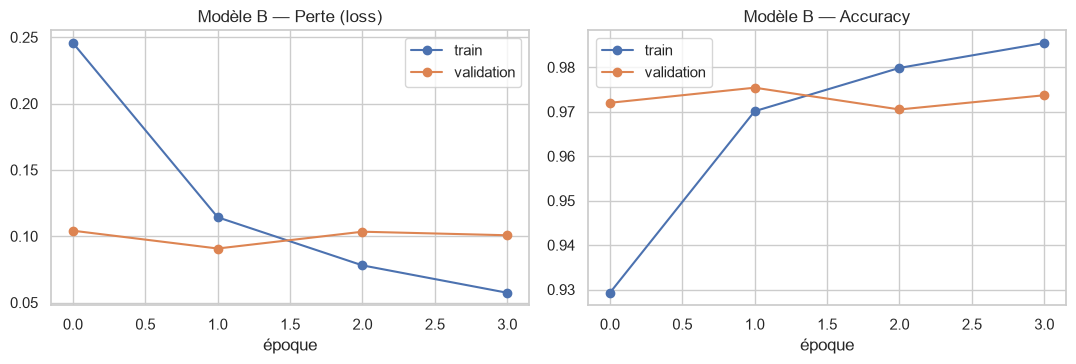

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for k, (metric, title) in enumerate([("loss", "Perte (loss)"), ("accuracy", "Accuracy")]):
    ax[k].plot(hist_b.history[metric], "o-", label="train")
    ax[k].plot(hist_b.history["val_" + metric], "o-", label="validation")
    ax[k].set_title(f"Modèle B — {title}"); ax[k].set_xlabel("époque"); ax[k].legend()
plt.tight_layout(); plt.savefig(f"{FIG}/model_b_training.png", dpi=150); plt.show()

## 6. Modèle C : CamemBERT (pré-entraîné)

**CamemBERT** est un modèle *Transformer* (même famille que BERT, issu de l'article *Attention Is All You Need*)
déjà entraîné sur 138 Go de texte français. Il « connaît » la langue : on l'**adapte** (*fine-tuning*) à notre tâche
en ajoutant une couche de classification et en l'entraînant quelques minutes/heures sur nos exemples.

Deux contraintes :
- **Longueur** : CamemBERT lit au maximum 512 *tokens*. On garde **256 tokens** et la **fin** des motivations
  (`truncation_side="left"`), là où la Cour conclut (« D'où il suit que le moyen n'est pas fondé »).
- **Temps de calcul** : ~4 exemples/seconde sur le GPU du Mac M4. On l'entraîne donc sur **20 000 décisions**
  (1 époque), et on l'évalue sur **le même test** que les autres modèles.

Important : CamemBERT reçoit le **texte brut** (pas les lemmes), car il a son propre découpage en sous-mots.

**Gain de temps :** si le dossier `models/camembert_finetuned` existe déjà, le modèle entraîné est **rechargé** au lieu d'être ré-entraîné (les sorties ci-dessous sont celles de l'entraînement d'origine, 91 min).

In [16]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

N_TRAIN_C = 300 if QUICK_TEST else 20_000
N_VAL_C = 100 if QUICK_TEST else 2_000
MAX_LEN, BATCH = 256, 16

train_c = train.sample(N_TRAIN_C, random_state=SEED)
val_c = val.sample(min(N_VAL_C, len(val)), random_state=SEED)

tokenizer = AutoTokenizer.from_pretrained("almanach/camembert-base")
tokenizer.truncation_side = "left"          # on garde la fin du texte

def encode(texts):
    return dict(tokenizer(list(texts), truncation=True, max_length=MAX_LEN, padding="max_length", return_tensors="np"))

print("Exemple de découpage en sous-mots :", tokenizer.tokenize("La cour d'appel a violé le texte susvisé")[:14])

enc_train, enc_val, enc_test = encode(train_c["motivations"]), encode(val_c["motivations"]), encode(test["motivations"])
ds_train = tf.data.Dataset.from_tensor_slices((enc_train, train_c["y"].values)).shuffle(10_000, seed=SEED).batch(BATCH)
ds_val = tf.data.Dataset.from_tensor_slices((enc_val, val_c["y"].values)).batch(64)
ds_test = tf.data.Dataset.from_tensor_slices(enc_test).batch(64)

Exemple de découpage en sous-mots : ['▁La', '▁cour', '▁d', "'", 'appel', '▁a', '▁viol', 'é', '▁le', '▁texte', '▁susvisé']


In [17]:
C_DIR = f"{MODELS}/camembert_finetuned"

if os.path.exists(f"{C_DIR}/tf_model.h5") and os.environ.get("RETRAIN_CAMEMBERT") != "1" and not QUICK_TEST:
    # Le modèle a déjà été entraîné (~1 h 30 sur le Mac M4) : on le recharge au lieu de recommencer.
    # Pour forcer un nouvel entraînement : lancer Jupyter avec RETRAIN_CAMEMBERT=1
    model_c = TFAutoModelForSequenceClassification.from_pretrained(C_DIR)
    t_train_c = pd.read_csv(f"{RESULTS}/model_comparison.csv", index_col=0).loc["C · CamemBERT (fine-tuné)", "temps_entraînement_s"]
    print(f"CamemBERT déjà entraîné : rechargé depuis {C_DIR} (entraînement initial : {t_train_c / 60:.1f} min)")
else:
    model_c = TFAutoModelForSequenceClassification.from_pretrained(
        "almanach/camembert-base", num_labels=len(LABELS), use_safetensors=False,
        id2label=dict(enumerate(LABELS)), label2id=label2id)

    steps = len(ds_train)
    lr = keras.optimizers.schedules.PolynomialDecay(2e-5, decay_steps=steps, end_learning_rate=0.0)  # le pas diminue jusqu'à 0
    model_c.compile(optimizer=keras.optimizers.legacy.Adam(learning_rate=lr),
                    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=["accuracy"])

    class Progress(keras.callbacks.Callback):
        """Écrit l'avancement dans un fichier (utile pour suivre un entraînement long)."""
        def on_train_batch_end(self, batch, logs=None):
            if batch % 50 == 0:
                with open(f"{RESULTS}/camembert_progress.txt", "w") as f:
                    f.write(f"batch {batch}/{steps} | loss {logs['loss']:.4f} | acc {logs['accuracy']:.4f} | {time.strftime('%H:%M:%S')}\n")

    t0 = time.time()
    hist_c = model_c.fit(ds_train, validation_data=ds_val, epochs=1, class_weight=CLASS_WEIGHT,
                         callbacks=[Progress()], verbose=2)
    t_train_c = time.time() - t0
    print(f"Entraînement CamemBERT : {t_train_c / 60:.1f} min")

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


All model checkpoint layers were used when initializing TFCamembertForSequenceClassification.



Some layers of TFCamembertForSequenceClassification were not initialized from the model checkpoint at almanach/camembert-base and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


1250/1250 - 5458s - loss: 0.3266 - accuracy: 0.9215 - val_loss: 0.1138 - val_accuracy: 0.9775 - 5458s/epoch - 4s/step


Entraînement CamemBERT : 91.0 min


In [18]:
t0 = time.time()
logits = model_c.predict(ds_test, verbose=0).logits
t_inf = time.time() - t0
pred_c = logits.argmax(1)

RESULTS_TABLE.append(evaluate("C · CamemBERT (fine-tuné)", test["y"], pred_c, t_train_c, t_inf, N_TRAIN_C))
VAL_SCORES["C · CamemBERT (fine-tuné)"] = f1_score(val_c["y"], model_c.predict(ds_val, verbose=0).logits.argmax(1), average="macro")
TEST_PREDS["C · CamemBERT"] = pred_c
print(classification_report(test["y"], pred_c, target_names=LABELS, digits=3))

model_c.save_pretrained(f"{MODELS}/camembert_finetuned")
tokenizer.save_pretrained(f"{MODELS}/camembert_finetuned")

C · CamemBERT (fine-tuné)                accuracy=0.9726  F1 macro=0.9550


                precision    recall  f1-score   support

         Rejet      0.991     0.977     0.984      5541
     Cassation      0.983     0.976     0.979      2560
Irrecevabilité      0.884     0.963     0.922       485
         Autre      0.918     0.952     0.935      1414

      accuracy                          0.973     10000
     macro avg      0.944     0.967     0.955     10000
  weighted avg      0.973     0.973     0.973     10000



('../models/camembert_finetuned/tokenizer_config.json',
 '../models/camembert_finetuned/special_tokens_map.json',
 '../models/camembert_finetuned/sentencepiece.bpe.model',
 '../models/camembert_finetuned/added_tokens.json',
 '../models/camembert_finetuned/tokenizer.json')

### Comparaison à données égales

CamemBERT n'a vu que 20 000 exemples, contre 80 000 pour A et B. Pour une comparaison **équitable**,
on ré-entraîne A et B sur **les mêmes 20 000 décisions**.

In [19]:
t0 = time.time()
a20 = make_pipeline(make_tfidf(), LogisticRegression(C=best_C, max_iter=2000, class_weight="balanced")).fit(train_c["lemmas"], train_c["y"])
t_tr = time.time() - t0
t0 = time.time(); p = a20.predict(test["lemmas"]); t_inf = time.time() - t0
RESULTS_TABLE.append(evaluate("A · TF-IDF + RL (20k)", test["y"], p, t_tr, t_inf, N_TRAIN_C))

b20 = build_model_b()
t0 = time.time()
b20.fit(to_ids(train_c["lemmas"]), train_c["y"].values, validation_data=(X_val_b, val["y"].values), epochs=10, batch_size=128,
        class_weight=CLASS_WEIGHT, callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)], verbose=0)
t_tr = time.time() - t0
t0 = time.time(); p = b20.predict(X_test_b, batch_size=512, verbose=0).argmax(1); t_inf = time.time() - t0
RESULTS_TABLE.append(evaluate("B · CNN Keras (20k)", test["y"], p, t_tr, t_inf, N_TRAIN_C))

A · TF-IDF + RL (20k)                    accuracy=0.9703  F1 macro=0.9534


B · CNN Keras (20k)                      accuracy=0.9670  F1 macro=0.9518


## 7. Comparaison des modèles

In [20]:
results = pd.DataFrame(RESULTS_TABLE).set_index("modèle")
results.to_csv(f"{RESULTS}/model_comparison.csv")
json.dump(VAL_SCORES, open(f"{RESULTS}/val_scores.json", "w"), ensure_ascii=False, indent=2)
results.round(4)

,n_train,accuracy,f1_macro,f1_Rejet,f1_Cassation,f1_Irrecevabilité,f1_Autre,temps_entraînement_s,temps_inférence_ms_par_doc
modèle,,,,,,,,,
Règles (sur le dispositif),0,0.9630,0.9327,0.9728,0.9885,0.8603,0.9093,0.0000,0.0091
A0 · TF-IDF + Naive Bayes,80000,0.8981,0.8874,0.9155,0.8606,0.8470,0.9266,8.9130,0.0660
A · TF-IDF + Régression logistique,80000,0.9788,0.9643,0.9879,0.9774,0.9283,0.9634,18.4874,0.0914
B · CNN Keras (de zéro),80000,0.9732,0.9589,0.9836,0.9672,0.9241,0.9606,111.0839,0.0740
C · CamemBERT (fine-tuné),20000,0.9726,0.9550,0.9840,0.9794,0.9220,0.9347,5457.8622,71.5780
A · TF-IDF + RL (20k),20000,0.9703,0.9534,0.9819,0.9652,0.9116,0.9549,6.0761,0.0773
B · CNN Keras (20k),20000,0.9670,0.9518,0.9789,0.9580,0.9160,0.9543,50.8694,0.0851


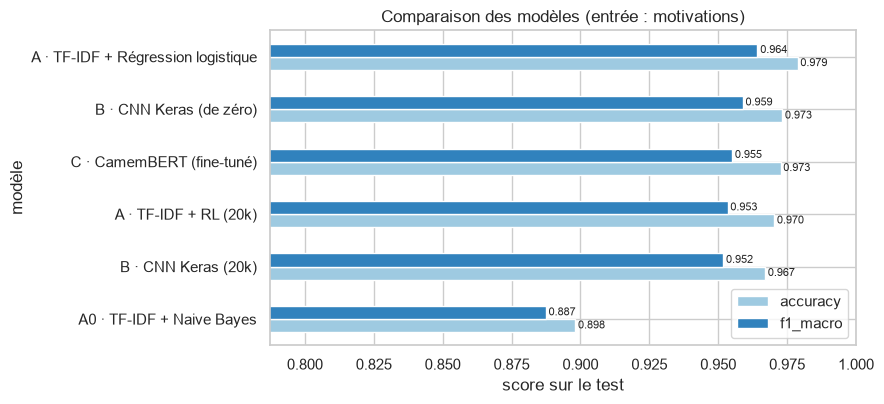

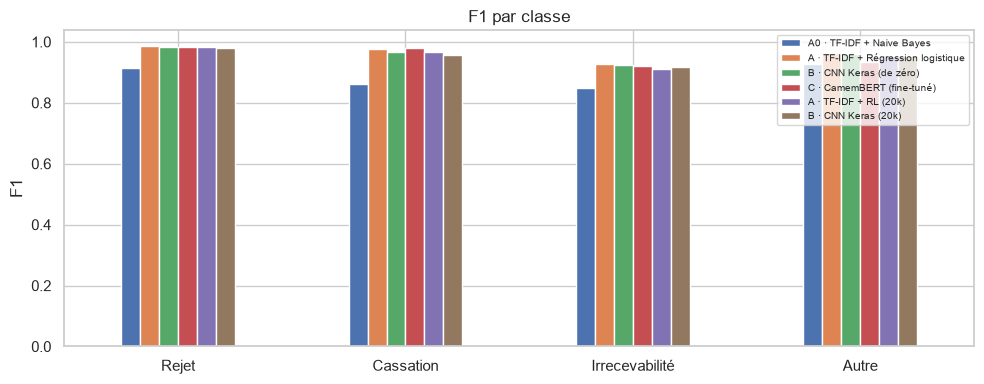

In [21]:
plot = results.drop(index="Règles (sur le dispositif)")[["accuracy", "f1_macro"]].sort_values("f1_macro")
ax = plot.plot.barh(figsize=(9, 4.2), color=["#9ecae1", "#3182bd"])
ax.set_xlim(max(0, plot.values.min() - 0.1), 1); ax.set_xlabel("score sur le test")
ax.set_title("Comparaison des modèles (entrée : motivations)")
for c in ax.containers: ax.bar_label(c, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout(); plt.savefig(f"{FIG}/model_comparison.png", dpi=150); plt.show()

per_class = results.drop(index="Règles (sur le dispositif)")[[f"f1_{l}" for l in LABELS]]
per_class.columns = LABELS
ax = per_class.T.plot.bar(figsize=(10, 4)); ax.set_ylabel("F1"); ax.set_title("F1 par classe")
plt.xticks(rotation=0); plt.legend(fontsize=7); plt.tight_layout(); plt.savefig(f"{FIG}/f1_per_class.png", dpi=150); plt.show()

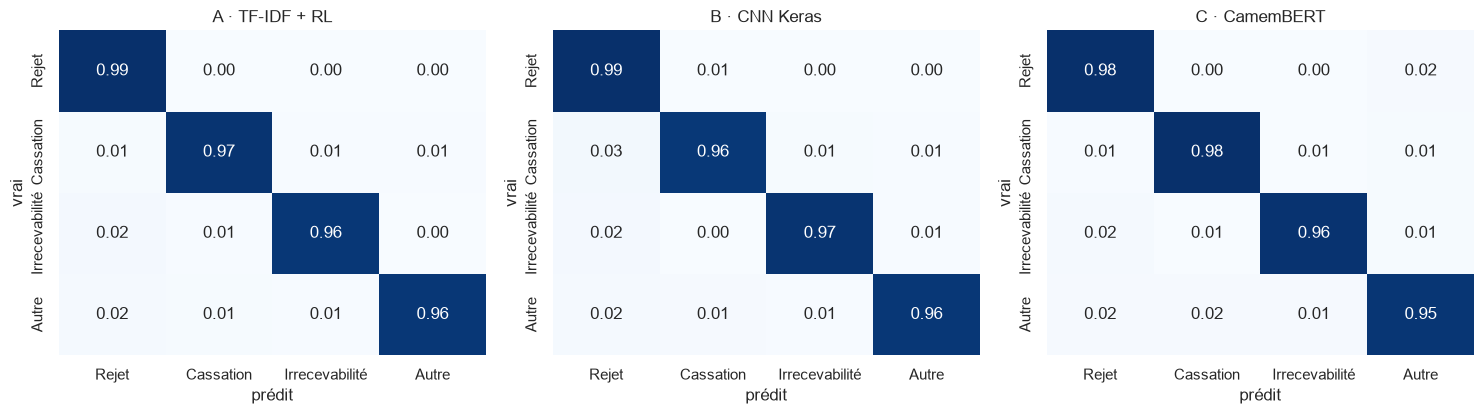

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, name in zip(axes, ["A · TF-IDF + RL", "B · CNN Keras", "C · CamemBERT"]):
    cm = confusion_matrix(test["y"], TEST_PREDS[name], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS, ax=ax, cbar=False)
    ax.set_title(name); ax.set_xlabel("prédit"); ax.set_ylabel("vrai")
plt.tight_layout(); plt.savefig(f"{FIG}/confusion_matrices.png", dpi=150); plt.show()

## 8. Analyse d'erreurs

On regarde **où** et **pourquoi** le meilleur modèle se trompe : par période (style d'écriture), puis quelques exemples.

In [23]:
best_name = max(VAL_SCORES, key=VAL_SCORES.get)       # choisi sur la VALIDATION, pas sur le test
print("Meilleur modèle (F1 macro validation) :", best_name)
key = {"A · TF-IDF + Régression logistique": "A · TF-IDF + RL", "B · CNN Keras (de zéro)": "B · CNN Keras",
       "C · CamemBERT (fine-tuné)": "C · CamemBERT"}.get(best_name, "A · TF-IDF + RL")

err = test[["date", "chamber", "label", "motivations"]].copy()
err["prédit"] = [LABELS[i] for i in TEST_PREDS[key]]
err["correct"] = err["label"] == err["prédit"]
err["période"] = pd.cut(err["date"].str[:4].astype(int), [0, 1999, 2018, 2100], labels=["avant 2000", "2000-2018", "2019+ (style direct)"])

by_p = err.groupby("période", observed=True)["correct"].agg(["mean", "size"]).rename(columns={"mean": "accuracy", "size": "nb"})
by_c = err.groupby("chamber")["correct"].agg(["mean", "size"]).rename(columns={"mean": "accuracy", "size": "nb"}).sort_values("accuracy")
by_p.to_csv(f"{RESULTS}/errors_by_period.csv"); by_c.to_csv(f"{RESULTS}/errors_by_chamber.csv")
display(by_p.round(3)); display(by_c.round(3))

Meilleur modèle (F1 macro validation) : A · TF-IDF + Régression logistique


,accuracy,nb
période,,
avant 2000,0.969,3204
2000-2018,0.980,4029
2019+ (style direct),0.988,2767


,accuracy,nb
chamber,,
Autre,0.500,2
Assemblée plénière,0.889,9
Chambre criminelle,0.971,2128
Chambre sociale,0.977,2553
Première chambre civile,0.979,1230
Chambre commerciale financière et économique,0.981,1201
Deuxième chambre civile,0.983,1358
Troisième chambre civile,0.988,1089
Première présidence (Ordonnance),0.988,429


In [24]:
confusions = err[~err["correct"]].groupby(["label", "prédit"]).size().sort_values(ascending=False).head(6)
display(confusions.to_frame("nb d'erreurs"))
for _, r in err[~err["correct"]].sample(min(4, (~err["correct"]).sum()), random_state=1).iterrows():
    print(f"--- vrai : {r['label']} | prédit : {r['prédit']} | {r['date']} | {r['chamber']}")
    print("…" + r["motivations"][-400:].replace("\n", " "), "\n")

nb d'erreurs
label     prédit                      
Autre     Rejet                     30
Cassation Rejet                     30
          Irrecevabilité            23
Rejet     Autre                     23
          Cassation                 21
Cassation Autre                     19

--- vrai : Cassation | prédit : Rejet | 1995-10-24 | Chambre commerciale financière et économique
…res, sur les sommes qui avaient été perçues par celui-ci, à compter du jour de leur versement, tout en relevant que les époux X... l'avaient assigné en paiement le 10 septembre 1990, la cour d'appel a violé le texte susvisé ;    Et attendu qu'il y a lieu, conformément à l'article 627, alinéa 2 du nouveau Code de procédure civile, de mettre fin au litige en appliquant la règle de droit appropriée ; 

--- vrai : Autre | prédit : Cassation | 2007-11-13 | Chambre sociale
…aire et indemnité compensatrice de congés payés au titre des heures de surveillance nocturne passées en chambre de veille" ; que c'est donc dans les limites du pourvoi, comme indiqué au dispositif, que l'arrêt prononcé le 13 juin 2007 a cassé l'arrêt de la cour d'appel de Caen du chef attaqué au bénéfice des seules demanderesses à l'exclusion de MM. X... et Y... ; que la requête n'est pas fondée ; 

--- vrai : Rejet | prédit

## 9. Test « en production » sur les PDF réels

Les 3 Bulletins PDF (mai à juillet **2026**) ont été transformés en JSON par `scripts/Txt_ToJSON.py`.
Ces décisions sont **plus récentes que toutes les données d'entraînement** (qui s'arrêtent en mars 2025) :
c'est un vrai test de généralisation. La bonne réponse est écrite dans l'en-tête du Bulletin (« – Cassation – »).

In [25]:
def header_to_label(h):
    if not h: return None
    if h.startswith("Cassation"): return "Cassation"
    return h if h in LABELS else "Autre"

docs = [json.load(open(f)) for f in sorted(glob.glob("../output/json/*.json"))]
prod = pd.DataFrame({"fichier": [d["source_file"] for d in docs],
                     "numéro": [d["metadata"]["case_number"] for d in docs],
                     "vrai": [header_to_label(d["outcome"]["verdict_header"]) for d in docs],
                     "règles": [d["outcome"]["verdict_rules"] for d in docs],
                     "reasoning": [d["outcome"]["reasoning"] for d in docs]}).dropna(subset=["vrai"])
prod = prod[prod["reasoning"].str.len() > 0]

prod_lemmas = [preprocess(d) for d in nlp.pipe(prod["reasoning"].str.slice(-6000))]
prod["A"] = [LABELS[i] for i in model_a.predict(prod_lemmas)]
prod["B"] = [LABELS[i] for i in model_b.predict(to_ids(prod_lemmas), verbose=0).argmax(1)]
enc = encode(prod["reasoning"])
prod["C"] = [LABELS[i] for i in model_c.predict(enc, batch_size=32, verbose=0).logits.argmax(1)]

prod_scores = pd.DataFrame({m: {"accuracy": accuracy_score(prod["vrai"], prod[m]),
                                "f1_macro": f1_score(prod["vrai"], prod[m], average="macro")}
                            for m in ["règles", "A", "B", "C"]}).T
prod_scores["nb arrêts"] = len(prod)
prod_scores.to_csv(f"{RESULTS}/production_pdf_scores.csv")
print("Répartition des vraies issues :", prod["vrai"].value_counts().to_dict())
prod_scores.round(3)

Répartition des vraies issues : {'Cassation': 49, 'Rejet': 46}


,accuracy,f1_macro,nb arrêts
règles,1.000,1.000,95
A,0.958,0.958,95
B,0.884,0.602,95
C,0.968,0.656,95


## 10. Sauvegarde du modèle final

Le modèle final est celui qui a le meilleur **F1 macro sur la validation**. On sauvegarde aussi A et B
pour que `scripts/predict.py` puisse les utiliser.

In [26]:
import joblib
joblib.dump(model_a, f"{MODELS}/model_a_tfidf_logreg.joblib")
model_b.save(f"{MODELS}/model_b_cnn.keras")
json.dump(vectorizer.get_vocabulary(), open(f"{MODELS}/model_b_vocabulary.json", "w"), ensure_ascii=False)

code_name = {"A · TF-IDF + Régression logistique": "A", "B · CNN Keras (de zéro)": "B", "C · CamemBERT (fine-tuné)": "C"}.get(best_name, "A")
final = {"final_model": code_name, "name": best_name, "val_f1_macro": VAL_SCORES[best_name],
         "labels": LABELS, "seq_len_b": SEQ_LEN, "max_len_c": MAX_LEN, "negations": NEGATIONS}
json.dump(final, open(f"{MODELS}/final_model.json", "w"), ensure_ascii=False, indent=2)
final

{'final_model': 'A',
 'name': 'A · TF-IDF + Régression logistique',
 'val_f1_macro': 0.9624698312876283,
 'labels': ['Rejet', 'Cassation', 'Irrecevabilité', 'Autre'],
 'seq_len_b': 300,
 'max_len_c': 256,
 'negations': ['ne',
  "n'",
  'n’',
  'pas',
  'non',
  'ni',
  'sans',
  'aucun',
  'aucune',
  'jamais']}